In [9]:
import numpy as np
import time
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Dense, Embedding
from sklearn.metrics import accuracy_score

In [3]:
# Load top 10,000 words
vocab_size = 10000
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [6]:
max_len = 200

X_train = pad_sequences(X_train, maxlen=max_len)
X_test = pad_sequences(X_test, maxlen=max_len)

In [7]:
def build_model(model_type):
    model = Sequential()
    
    # Embedding Layer
    model.add(Embedding(input_dim=vocab_size, output_dim=32, input_length=max_len))
    
    if model_type == "RNN":
        model.add(SimpleRNN(32))
    elif model_type == "LSTM":
        model.add(LSTM(32))
    elif model_type == "GRU":
        model.add(GRU(32))
    
    model.add(Dense(1, activation='sigmoid'))
    
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    
    return model

In [10]:
results = {}

for model_type in ["RNN", "LSTM", "GRU"]:
    print(f"\nTraining {model_type}...")
    
    model = build_model(model_type)
    
    start_time = time.time()
    model.fit(X_train, y_train, epochs=3, batch_size=64, verbose=1)
    training_time = time.time() - start_time
    
    # Predictions
    y_pred = (model.predict(X_test) > 0.5).astype("int32")
    
    acc = accuracy_score(y_test, y_pred)
    
    results[model_type] = {
        "Accuracy": acc,
        "Time": training_time
    }
    
    print(f"{model_type} -> Accuracy: {acc:.4f}, Time: {training_time:.2f}s")


Training RNN...
Epoch 1/3


c:\Users\prate\Desktop\ZTMmine\env\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.6700 - loss: 0.5773
Epoch 2/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.8580 - loss: 0.3439
Epoch 3/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9166 - loss: 0.2194
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step
RNN -> Accuracy: 0.8438, Time: 18.51s

Training LSTM...
Epoch 1/3


c:\Users\prate\Desktop\ZTMmine\env\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


391/391 ━━━━━━━━━━━━━━━━━━━━ 21s 50ms/step - accuracy: 0.7768 - loss: 0.4630
Epoch 2/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 13s 33ms/step - accuracy: 0.9036 - loss: 0.2500
Epoch 3/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 13s 33ms/step - accuracy: 0.9302 - loss: 0.1845
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step
LSTM -> Accuracy: 0.8624, Time: 46.87s

Training GRU...
Epoch 1/3


c:\Users\prate\Desktop\ZTMmine\env\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


391/391 ━━━━━━━━━━━━━━━━━━━━ 16s 37ms/step - accuracy: 0.7752 - loss: 0.4527
Epoch 2/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - accuracy: 0.8927 - loss: 0.2686
Epoch 3/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 15s 37ms/step - accuracy: 0.9257 - loss: 0.1972
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step
GRU -> Accuracy: 0.8474, Time: 45.18s


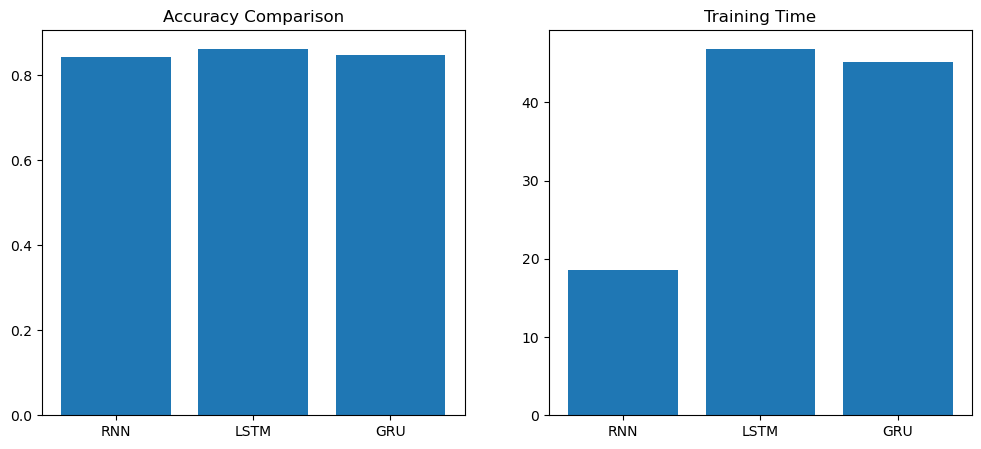

In [11]:
models = list(results.keys())
acc_values = [results[m]["Accuracy"] for m in models]
time_values = [results[m]["Time"] for m in models]

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.bar(models, acc_values)
plt.title("Accuracy Comparison")

plt.subplot(1,2,2)
plt.bar(models, time_values)
plt.title("Training Time")

plt.show()